# Using the trained multilayer perceptron
This notebook will walk you through the basic usage of the trained multilayer perceptron (MLP) that is included in this addition to supersonic-effects.

The MLP included here is trained to predict the global average change in the ozone column (in dobson unit /DU) and changes in global radiative forcing (in mW/m2, stratospherically adjusted) based on supersonic fleet design characteristics such as the cruise altitude, the total annual fuel burn, and the composition of the fleetwide emissions. This MLP is trained and used in the peer-reviewed work " " by J.A. van 't Hoff, V. Grewe, and I.C. Dedoussi, published in Environmental Data Science (DOI: to_be_added). We refer to this work for a detailed description of this model and the input data.

The trained model is saved in ONNX format and should be easy to load into any existing python environment with the onnxruntime library.

## 1. Loading the model
Loading the model is simple with onnxruntime.

In [ ]:
# workaround for jupyter notebook where we cannot do a relative import
import os, sys
dir2 = os.path.abspath('')
dir1 = os.path.dirname(dir2)
if not dir1 in sys.path: sys.path.append(dir1)

from multilayer_perceptron.load_mlp import load_mlp

sess = load_mlp()

## 2. Supersonic fleet configuration
This MLP expects 6 inputs that describe the cruise altitude, the fleetwide annual fuel burn, and the fleetwide average emission indices of the supersonic aircraft fleet.
The input variables and respective training and testing ranges are as follows:

- **Cruise altitude**: The mean fleetwide cruise altitude in km. The training and testing range is 16.17-19.83 km
- **Annual fuel burn**: The annual supersonic fleet fuel consumption in Tg/yr. The training and testing range is 0-174 Tg / yr
- **NOx emissions**: The mean fleetwide emission index of NOx in g/kg. The training and testing range is 0 - 22 g/kg
- **Sulphur emissions**: The mean fleetwide emission index of SO2 in g/kg. The training and testing range is 0-1.0 g/kg (~ 0-720 ppm sulphur)
- **H2O emissions**: The mean fleetwide emission index of H2O in kg/kg. The training and testing range is 0-5.53 kg/kg
- **Black carbon emissions**: The mean fleetwide emission index of BC in g/kg. The training and testing range is 0 - 6.5 mg/kg

[!CAUTION]  
It is possible to provide the MLP with data outside of the training and testing range, but the reliability and accuracy of these results are not guaranteed. For validation of results within the training and testing range, see the associated work.

In [4]:
### Aircraft configuration
cruise_altitude = 18.3  # Mean fleetwide cruise altitude (km). Training range 16.17 - 19.83
annual_fb_tg = 60       # Annual fleet fuel burn (Tg). Training range 0-174 Tg / yr
ei_nox = 10             # Fuel specific emission index of NOx (g / kg). Training range 0 - 22 g/kg
ei_so2 = 0.3            # Fuel specific emission index of SO2 (g / kg). Training range 0-1.0 g/kg ( ~ 0-720 ppm sulphur)
ei_h2o = 1.3            # Fuel specific emission index of H2O (kg / kg). Training range 0-5.53 kg/kg
ei_bc = 0.003           # Fuel specific emission index of BC (g / kg). Training range 0 - 6.5 mg/kg

## 3. Making predictions with the model
Using the .run() function of the ONNX runtime the MLP can be used to evaluate data. The session needs input of 2-dimensional arrays for the day of the year (1-365), X_Cruise_alt, X_Tg_FB, X_EI_NOx, X_EI_SO2, X_EI_H2O, and X_EI_BC variables. It outputs an array with 5 variables: Global mean change in the ozone column (DU) and the global mean radiative forcing from O3, H2O, BC, and inorganic aerosols.

The example below predicts year-round changes in the ozone column and radiative forcing:

(1.0, 365.0)

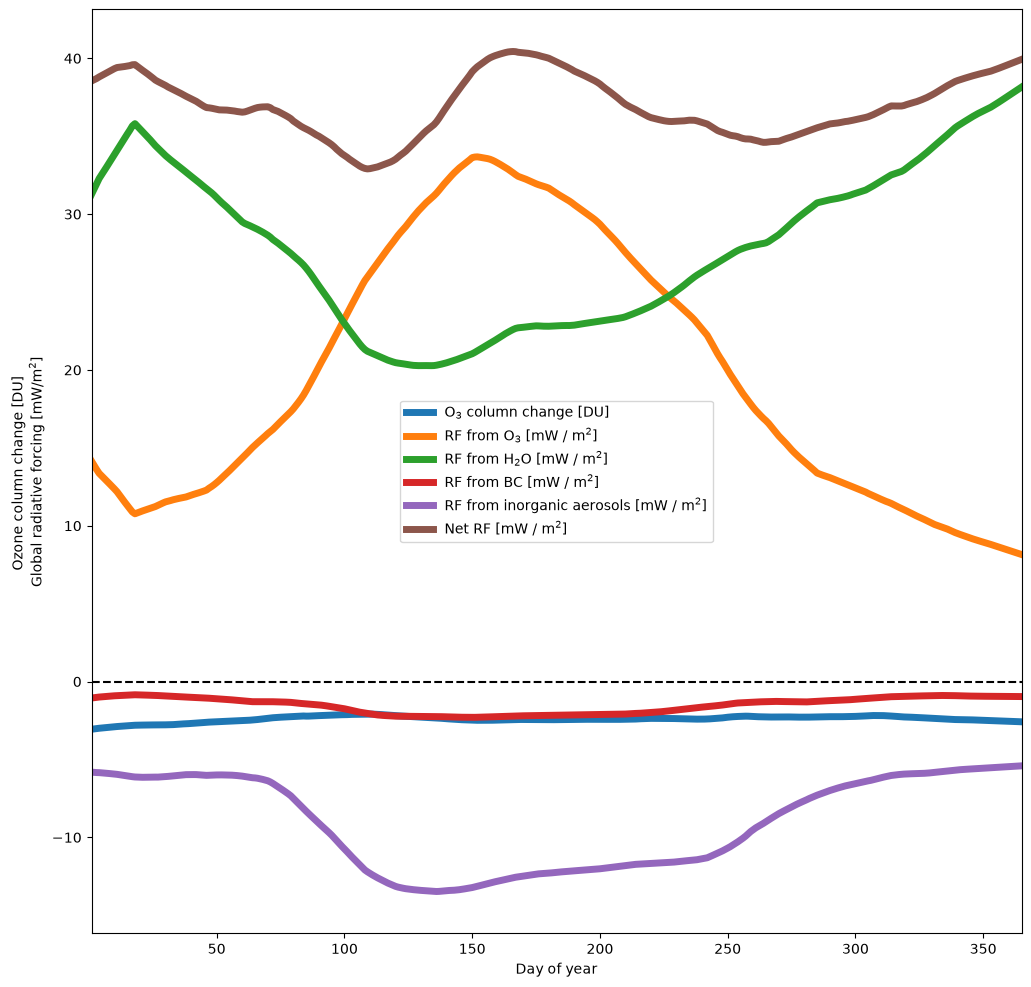

In [5]:
import matplotlib.pyplot as pp
import numpy as np

# Predict for a year
model_predictions = np.zeros((365,5))
for day_of_year in range (1,366):

    output = sess.run(
        None, # output name, not used here
        {
            "datemonth": [[day_of_year]],
            "X_Cruise_alt": [[cruise_altitude]],
            "X_Tg_FB": [[annual_fb_tg]],
            "X_EI_NOx": [[ei_nox]],
            "X_EI_SO2": [[ei_so2]],
            "X_EI_H2O": [[ei_h2o]],
            "X_EI_BC": [[ei_bc]],
        },
    )[0] # It outputs a 2d array, in this case we need the first component only
    
    model_predictions[day_of_year-1,:] = output.T

## Decompose the predictions into different variables
delta_O3_column_DU = model_predictions[:,0]
delta_RF_O3 = model_predictions[:,1]
delta_RF_H2O = model_predictions[:,2]
delta_RF_BC = model_predictions[:,3]
delta_RF_IA = model_predictions[:,4]
delta_RF_net = delta_RF_O3 + delta_RF_H2O + delta_RF_BC + delta_RF_IA

fig,ax = pp.subplots(figsize=(12,12))
x = np.arange(1,366)
ax.plot(x, delta_O3_column_DU, label="O$_3$ column change [DU]",linewidth=5)
ax.plot(x, delta_RF_O3, label="RF from O$_3$ [mW / m$^2$]",linewidth=5)
ax.plot(x, delta_RF_H2O, label="RF from H$_2$O [mW / m$^2$]",linewidth=5)
ax.plot(x, delta_RF_BC, label="RF from BC [mW / m$^2$]",linewidth=5)
ax.plot(x, delta_RF_IA, label="RF from inorganic aerosols [mW / m$^2$]",linewidth=5)
ax.plot(x, delta_RF_net, label="Net RF [mW / m$^2$]",linewidth=5)
ax.hlines(0,1,365, color='k',ls="--")

ax.set_ylabel("Ozone column change [DU] \nGlobal radiative forcing [mW/m$^2$]")
ax.set_xlabel("Day of year")
ax.legend()
ax.set_xlim(1,365)